In [39]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
# Summarize paths
dataset_parent_dir = '../raw_dataset'

dataset_dirs = [
    'Folio', 'LogiQA', 'ProofWriter', 'ReClor', 'RuleTaker'
]

train_paths = []
valid_paths = []

for dataset in dataset_dirs:
    train_path = os.path.join(dataset_parent_dir, dataset, f'{dataset.lower()}_train.json')
    valid_path = os.path.join(dataset_parent_dir, dataset, f'{dataset.lower()}_valid.json')
    
    if os.path.isfile(train_path):
        train_paths.append(train_path)
    if os.path.isfile(valid_path):
        valid_paths.append(valid_path)
        
test_paths = [
    os.path.join(dataset_parent_dir, 'Folio/folio_test.json'),
    os.path.join(dataset_parent_dir, 'ReClor/reclor_test.json'),
    os.path.join(dataset_parent_dir, 'LogiQA/logiqa_test.json'),
    os.path.join('../gen_data', 'Bao.json'),
    os.path.join('../gen_data', 'Canh.json'),
    os.path.join('../gen_data', 'Hao.json'),
    os.path.join('../gen_data', 'Khoi.json'),
    os.path.join('../gen_data', 'Tri.json')
]

In [22]:
train_df_list = []
valid_df_list = []
test_df_list = []

for file in train_paths:
    if 'gen_data' in file:
        df = pd.read_json(file)[['premises', 'label']]
    else:
        df = pd.read_json(file)
        df = df.rename(columns=lambda x: x.replace('premise', 'premises').replace('premisess', 'premises'))
        df = df[['nat_premises', 'label']]
        df = df.rename(columns={'nat_premises': 'premises'})
        
    train_df_list.append(df)
    
for file in valid_paths:
    if 'gen_data' in file:
        df = pd.read_json(file)[['premises', 'label']]
    else:
        df = pd.read_json(file)
        df = df.rename(columns=lambda x: x.replace('premise', 'premises').replace('premisess', 'premises'))
        df = df[['nat_premises', 'label']]
        df = df.rename(columns={'nat_premises': 'premises'})
        
    valid_df_list.append(df)

for file in test_paths:
    if 'gen_data' in file:
        df = pd.read_json(file)[['premises', 'label']]
    else:
        df = pd.read_json(file)
        df = df.rename(columns=lambda x: x.replace('premise', 'premises').replace('premisess', 'premises'))
        df = df[['nat_premises', 'label']]
        df = df.rename(columns={'nat_premises': 'premises'})
        
    test_df_list.append(df)

train_df = pd.concat(train_df_list, ignore_index=True)
valid_df = pd.concat(valid_df_list, ignore_index=True)
test_df = pd.concat(test_df_list, ignore_index=True)

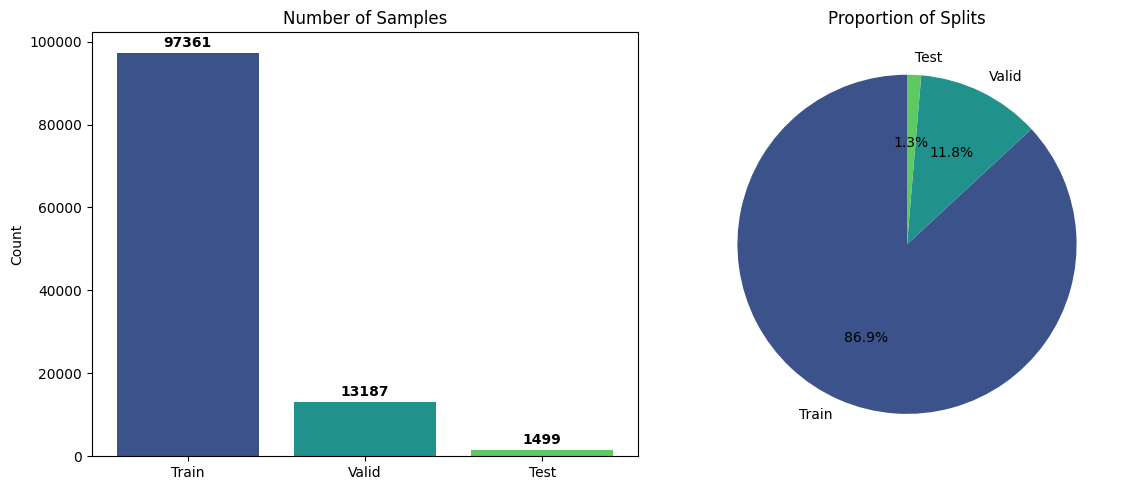

In [64]:
# Number of samples
counts = {
    'Train': len(train_df),
    'Valid': len(valid_df),
    'Test': len(test_df)
}

s_counts = pd.Series(counts).sort_values(ascending=False)
palette = sns.color_palette("viridis", len(s_counts))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
bars = ax1.bar(s_counts.index, s_counts.values, color=palette)
ax1.bar_label(bars, padding=2, fontsize=10, fontweight='bold')
ax1.set_title('Number of Samples')
ax1.set_ylabel('Count')

ax2.pie(s_counts.values, labels=s_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=palette)
ax2.set_title('Proportion of Splits')

plt.tight_layout()
plt.show()

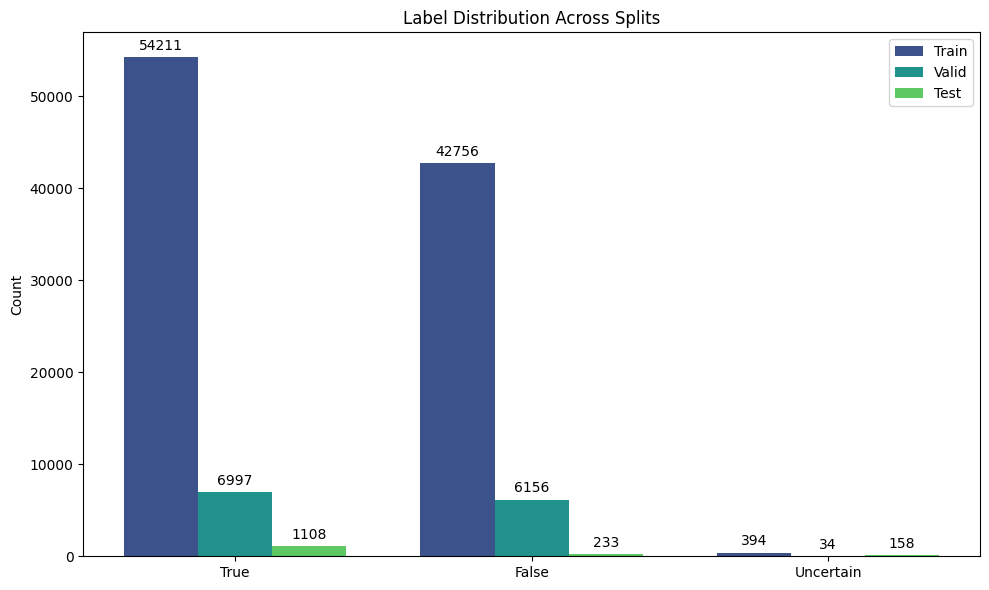

In [50]:
# Label distribution
labels = train_df['label'].unique()

train_counts = list(train_df['label'].value_counts().reindex(labels, fill_value=0))
valid_counts = list(valid_df['label'].value_counts().reindex(labels, fill_value=0))
test_counts = list(test_df['label'].value_counts().reindex(labels, fill_value=0))

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.25
palette = sns.color_palette("viridis", 3)

rects1 = ax.bar(x - width, train_counts, width, label='Train', color=palette[0])
rects2 = ax.bar(x, valid_counts, width, label='Valid', color=palette[1])
rects3 = ax.bar(x + width, test_counts, width, label='Test', color=palette[2])

ax.set_ylabel('Count')
ax.set_title('Label Distribution Across Splits')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)
ax.bar_label(rects3, padding=3)

plt.tight_layout()
plt.show()

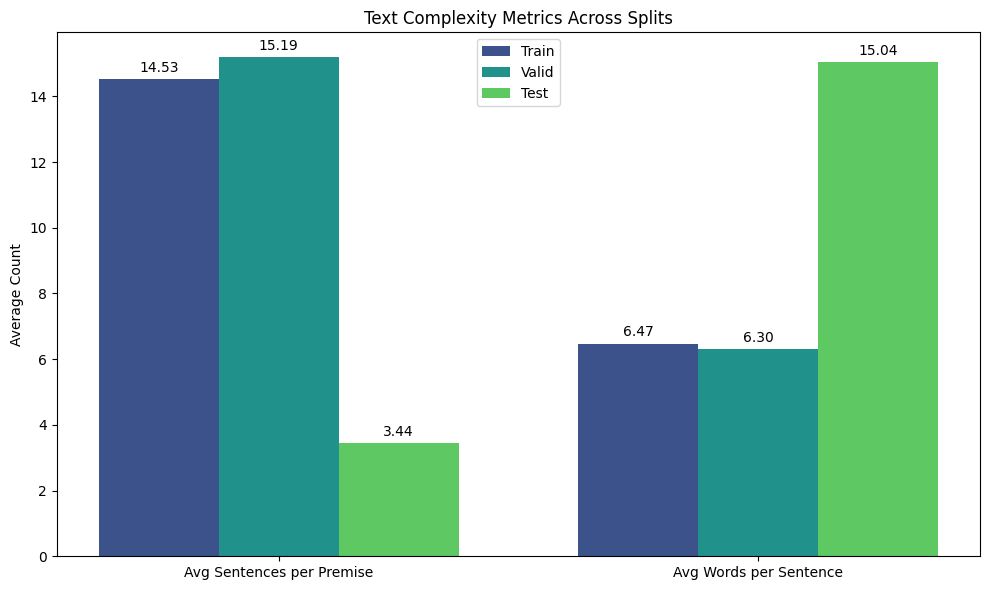

In [60]:
def get_metrics(df):
    avg_sentences = df['premises'].str.count(r'[.!?]+').mean()
    avg_words = df['premises'].apply(lambda x: len(str(x).split())).mean() / avg_sentences
    return avg_sentences, avg_words

train_metrics = get_metrics(train_df)
val_metrics = get_metrics(valid_df)
test_metrics = get_metrics(test_df)

categories = ['Avg Sentences per Premise', 'Avg Words per Sentence']
train_vals = [train_metrics[0], train_metrics[1]]
val_vals = [val_metrics[0], val_metrics[1]]
test_vals = [test_metrics[0], test_metrics[1]]

x = np.arange(len(categories))
width = 0.25 
palette = sns.color_palette("viridis", 3)

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width, train_vals, width, label='Train', color=palette[0])
rects2 = ax.bar(x, val_vals, width, label='Valid', color=palette[1])
rects3 = ax.bar(x + width, test_vals, width, label='Test', color=palette[2])

ax.set_ylabel('Average Count')
ax.set_title('Text Complexity Metrics Across Splits')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='upper center', frameon=True)

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

plt.tight_layout()
plt.show()